Computing a global dendrogram by merging local dendrograms
==========================================================

Let's start by doing some imports and defining the data

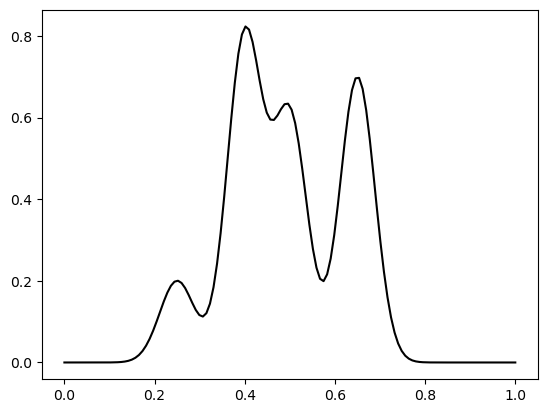

In [1]:
import heat as ht
import numpy as np
import matplotlib.pyplot as plt
from dendro.utils import get_1d_data
from astrodendro.dendrogram import Dendrogram
from astrodendro.structure import Structure

x, data = get_1d_data(128)
x = x.numpy()
data = data.numpy()

plt.plot(x, data, color="black")

reference_dendrogram = Dendrogram.compute(data)

Next, we are going to split up the data into chunks that we will compute the dendrograms independently on.

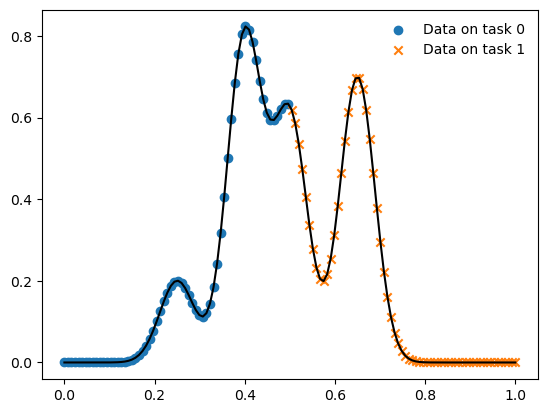

In [2]:
ntasks = 2
elements_per_task = data.shape[0] // ntasks
local_slices = [
    slice(i * elements_per_task, (i + 1) * elements_per_task) for i in range(ntasks)
]


plt.plot(x, data, color="black")
for i, s in enumerate(local_slices):
    marker = "o" if i % 2 == 0 else "x"
    plt.scatter(x[s], data[s], marker=marker, label=f"Data on task {i}")
plt.legend(frameon=False)

Next, we simply compute dendrograms on the local data.
After we have computed them, we add the shift from local data to global data.

In [3]:

local_dendrograms = [Dendrogram.compute(np.array(data[s])) for s in local_slices]


def add_offset_to_astrodendro_data(offset, leaves):
    for leaf in leaves:
        leaf._indices = np.array([index[0] + offset for index in leaf._indices])
        add_offset_to_astrodendro_data(offset, leaf._children)


for i in range(ntasks):
    add_offset_to_astrodendro_data(
        offset=local_slices[i].start, leaves=local_dendrograms[i].trunk
    )

Let's plot the local dendrograms

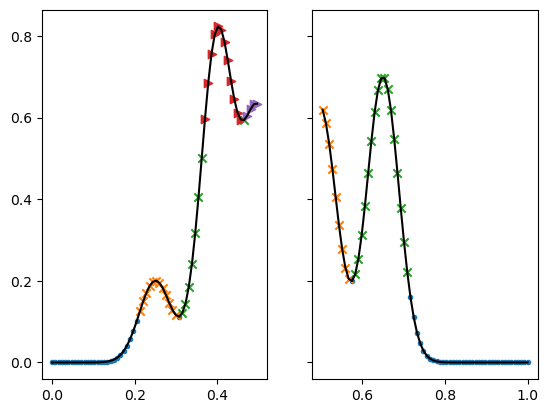

In [4]:
def plot_astrodendro_leaves(ax, leaves, level=0):
    markers = {0: ".", 1: "x", 2: ">", 3: "o", "4": "<"}
    for leaf in leaves:
        ax.scatter(
            np.array(x)[leaf._indices],
            np.array(data)[leaf._indices],
            marker=markers[level],
        )
        plot_astrodendro_leaves(ax=ax, leaves=leaf._children, level=level + 1)


def plot_local_dendrograms(local_dendrograms):
    fig, axs = plt.subplots(1, ntasks, sharey=True)
    for i in range(ntasks):
        ax = axs[i] if ntasks > 1 else axs
        ax.plot(x[local_slices[i]], data[local_slices[i]], color="black")

        plot_astrodendro_leaves(ax, local_dendrograms[i].trunk)
plot_local_dendrograms(local_dendrograms)

Let's try and merge two adjacent dendrograms
We start by listing the ranges of all the structures

In [5]:

def get_structure_ranges(dendrogram):
    return {s: (s._vmin, s._vmax) for s in dendrogram.all_structures}

local_ranges = [get_structure_ranges(dendrogram) for dendrogram in local_dendrograms]

def print_local_ranges(local_ranges):
    print('Values in local structures range from ... to ...')
    for i, ranges in enumerate(local_ranges):
        print(f'Task {i}:')
        for _range in ranges.values():
            print(f'      {_range[0]:.2f} to {_range[1]:.2f}')
print_local_ranges(local_ranges)

Values in local structures range from ... to ...
Task 0:
      0.00 to 0.11
      0.12 to 0.20
      0.12 to 0.59
      0.60 to 0.82
      0.60 to 0.63
Task 1:
      0.00 to 0.20
      0.21 to 0.62
      0.22 to 0.70


Let's start by chunking the structures.
This would involve gathering the data in a parallel setup.

In [6]:

all_ranges = []
for _local_range in local_ranges:
    all_ranges += list(_local_range.values())

all_structures = []
for dendrogram in local_dendrograms:
    all_structures += [me for me in dendrogram.all_structures]

local_extrema = [structure._vmin for structure in all_structures] + [structure._vmax for structure in all_structures]
local_extrema = sorted(local_extrema)

chunks = []
for structure in all_structures:
    indices = np.array(structure._indices)
    values = np.array(structure._values)

    start_idx = local_extrema.index(structure._vmin)
    stop_idx = local_extrema.index(structure._vmax)

    chunk_along = local_extrema[start_idx+1:stop_idx]

    if len(chunk_along) == 0:
        chunks.append(indices)
    else:
        for extremum in chunk_along:
            mask = values <= extremum

            chunk = indices[mask]
            if chunk.shape != (0,):
                chunks.append(chunk)

            indices = indices[~mask]
            values = values[~mask]

        if indices.shape != (0,):
            chunks.append(indices)

print(f'Split the global dendrogram with {data.shape[0]} data points into {len(chunks)} chunks')

Split the global dendrogram with 128 data points into 21 chunks


Next, we plot the chunks and the reference diagram side-by-side.

Text(0.5, 1.0, 'Full dendrogram')

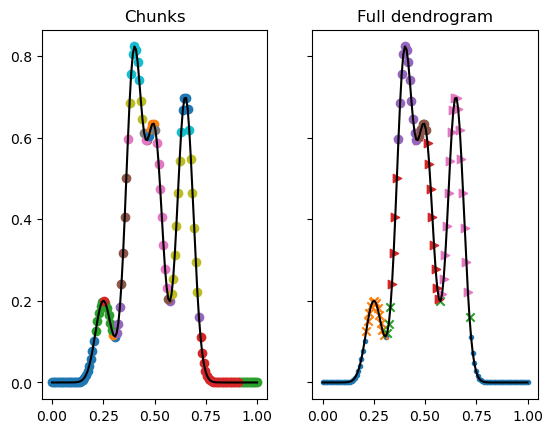

In [7]:
fig, axs = plt.subplots(1, 2, sharey=True)
axs[0].plot(x, data, color='black')
axs[1].plot(x, data, color='black')
for chunk in chunks:
    axs[0].scatter(x[chunk], data[chunk])
plot_astrodendro_leaves(axs[1], reference_dendrogram.trunk)
axs[0].set_title('Chunks')
axs[1].set_title('Full dendrogram')

Looks about right: The chunks are smaller than the structures and no chunk is part of two structures.
We can actually do a rigorous test that this the chunking satisfies this and also covers all data.

In [8]:
assert np.allclose(np.sort(np.concatenate(chunks)), np.arange(data.shape[0]))
for structure in reference_dendrogram.all_structures:
    for chunk in chunks:
        if np.any(np.isin(chunk, structure._indices)):
            assert np.all(np.isin(chunk, structure._indices))

Alright, now we need to merge these chunks to one global dendrogram by following the same rules of the local dendrograms, but applied to the chunks.
Step one is to sort the chunks because we will assemble the tree from the top.

In [9]:
chunk_max_vals = [data[chunk].max() for chunk in chunks]
chunks = [chunks[i] for i in np.argsort(chunk_max_vals)[::-1]]

Before we can assemble the dendrogram, we need to determine whether two chunks are adjacent.

In [10]:
def is_adjacent(chunkA, chunkB):
    if np.any(np.isin(chunkA +1, chunkB)):
        return True
    elif np.any(np.isin(chunkA -1, chunkB)):
        return True
    return False

Let's check the function with a few examples

Chunk A is not adjacent to chunk B
Chunk A is adjacent to chunk C


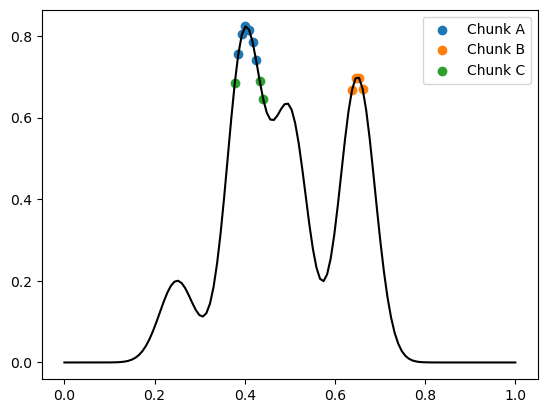

In [11]:
chunkA = chunks[0]
chunkB = chunks[1]
chunkC = chunks[2]

fig, ax = plt.subplots()
ax.plot(x, data, color='black')
ax.scatter(x[chunkA], data[chunkA], label='Chunk A')
ax.scatter(x[chunkB], data[chunkB], label='Chunk B')
ax.scatter(x[chunkC], data[chunkC], label='Chunk C')
ax.legend()

print(f'Chunk A is{"" if is_adjacent(chunkA, chunkB) else " not"} adjacent to chunk B')
print(f'Chunk A is{"" if is_adjacent(chunkA, chunkC) else " not"} adjacent to chunk C')
assert not is_adjacent(chunkA, chunkB)
assert is_adjacent(chunkA, chunkC)

Now, we are ready to compute the full dendrogram.
To this end, we loop through all the chunks and assign them to structures.
In each iteration, we do:
- Compute number of adjacent structures we already have in the tree
- If there no adjacent structures, we create a new leaf
- If there is exactly one adjacent structure, we merge the structures
- If there are two adjacent structures, we create a new branch as parent to the two adjacent structures

In [12]:
merged_dendrogram = Dendrogram()

def is_adjacent_to_structure(chunk, structure):
    if is_adjacent(chunk, structure._indices):
        return True
    else:
        return any(is_adjacent_to_structure(chunk, child) for child in structure._children)

# start with the first leaf
structures = [Structure(chunks[0], data[chunks[0]], dendrogram=merged_dendrogram)]

# loop through all other leafs and assign them to structures
for chunk in chunks[1:]:
    adjacent_structures = [structure for structure in structures if is_adjacent_to_structure(chunk, structure) and structure.parent is None]

    if len(adjacent_structures) == 0:  # create new leaf
        structures.append(Structure(chunk, data[chunk], dendrogram=merged_dendrogram))

    elif len(adjacent_structures) == 1:  # merge into existing structure
        for idx in chunk:
            adjacent_structures[0]._add_pixel(idx, data[idx])

    elif len(adjacent_structures) == 2:  # create parent structure
        structures.append(Structure(chunk, data[chunk], children=adjacent_structures, dendrogram=merged_dendrogram))

    else:
        raise Exception(f'Chunk is adjacent to {len(adjacent_structures)} structures, which is not supposed to happen')

# identify trunk
merged_dendrogram._trunk = [structure for structure in structures if structure.parent is None]

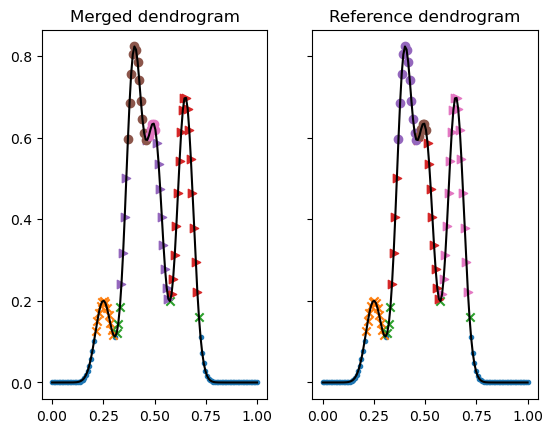

In [13]:
fig, axs = plt.subplots(1, 2, sharey=True)
axs[0].plot(x, data, color='black')
axs[1].plot(x, data, color='black')
plot_astrodendro_leaves(axs[0], merged_dendrogram.trunk)
plot_astrodendro_leaves(axs[1], reference_dendrogram.trunk)
axs[0].set_title('Merged dendrogram')
axs[1].set_title('Reference dendrogram')

for structure in reference_dendrogram.all_structures:
    corresponds_to = [ref_struct for ref_struct in merged_dendrogram.all_structures if np.any(np.isin(structure._indices, ref_struct._indices))]
    assert len(corresponds_to) == 1, f'Structure in reference dendrogram corresponds to {len(corresponds_to)} structures in the merged one'
    assert np.allclose(np.sort(np.array(structure._indices).flatten()), np.sort(np.array(corresponds_to[0]._indices).flatten())), 'Indices dont match between merged and reference structure'

Success!

In [14]:
if __name__ == "__main__":
    plt.show()